# Voteview — discovery to plot

The narrative arc, entirely over MCP: find what exists, fetch it, plot it. No
local files, no knowledge of how the series were built.

That last part is the test. Voteview needed no server work — it reuses the
stored-series tools WONDER and NVSR use — so if this notebook reads naturally,
the abstraction holds.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("../")
sys.path.append("../../")

from matplotlib import pyplot
from lib import config
from utils import search_catalog, get_series, plot_series, plot_group, to_arrays

pyplot.style.use(config.glyfish_style)

## 1. Discovery

Start from the catalog, not from knowing an id. Two facets: `measure` and
`chamber`.

In [2]:
entries = sorted(await search_catalog(), key=lambda e: e["series_id"])
print(f"{len(entries)} Voteview series\n")
for e in entries:
    facets = e.get("facets") or {}
    print(f"  {facets.get('measure',''):26s} {facets.get('chamber',''):7s} "
          f"{e['observation_start']}..{e['observation_end']}")


8 Voteview series

  effective_parties          house   1789-01-01..2025-01-01
  effective_parties          senate  1789-01-01..2025-01-01
  median_gap                 house   1857-01-01..2025-01-01
  median_gap                 senate  1857-01-01..2025-01-01
  moderate_bloc              house   1857-01-01..2025-01-01
  moderate_bloc              senate  1857-01-01..2025-01-01
  party_predicts_position    house   1789-01-01..2025-01-01
  party_predicts_position    senate  1789-01-01..2025-01-01


Four measures, two chambers. Note the two different spans — that is not an
accident of coverage, it is what each measure can express. Two of them never
name a party, so they reach 1789; the other two compare Democrats to
Republicans, who do not both exist before 1857.

## 2. Fetch

The catalog's `retrieval` block says which tool serves a series, so a consumer
never has to know that Voteview is stored rather than live.

In [3]:
target = next(e for e in entries
              if (e.get("facets") or {}).get("measure") == "median_gap"
              and (e.get("facets") or {}).get("chamber") == "house")
print("  retrieval:", target["retrieval"])

series = await get_series(target["retrieval"]["native_id"])
years, values = to_arrays(series)
print(f"\n  {series['title']}")
print(f"  {len(years)} observations, {years[0]}-{years[-1]}, every {years[1]-years[0]} years")
print(f"  lowest  {values.min():.3f} in {years[values.argmin()]}")
print(f"  highest {values.max():.3f} in {years[values.argmax()]}")

  retrieval: {'tool': 'timeseries_source_data', 'source': 'voteview', 'native_id': 'voteview/median_gap/house'}

  Distance between the party medians — US House
  85 observations, 1857-2025, every 2 years
  lowest  0.497 in 1947
  highest 0.925 in 2025


## 3. Plot

The distance between the two parties' medians, 1857 to today.

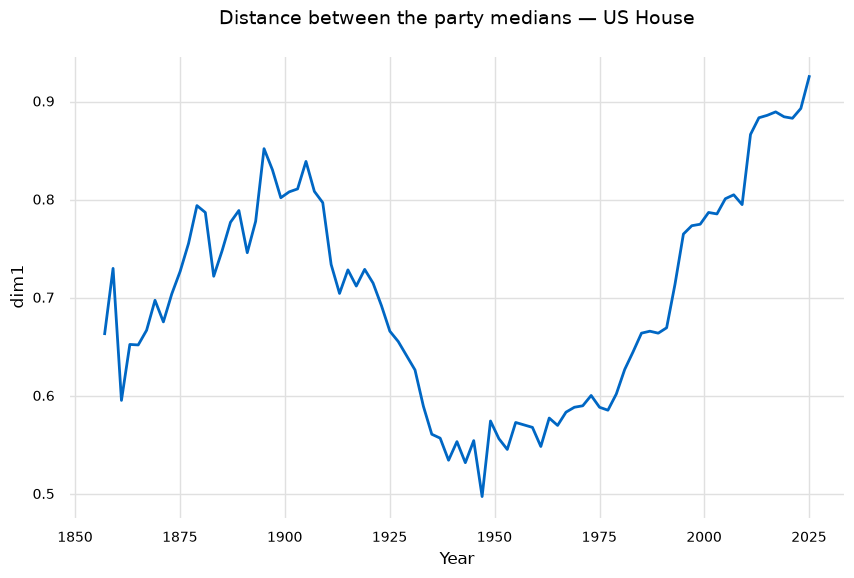

In [4]:
plot_series(series)

A peak around 1900, the postwar trough, and a climb since the 1970s past the
Gilded Age. The 1947 low of 0.498 is the closest the two parties have ever
been.

## 4. The comparison that changes the reading

The gap alone suggests a smooth return to an earlier state. Overlaying the
count of members who sit *between* the parties says otherwise.

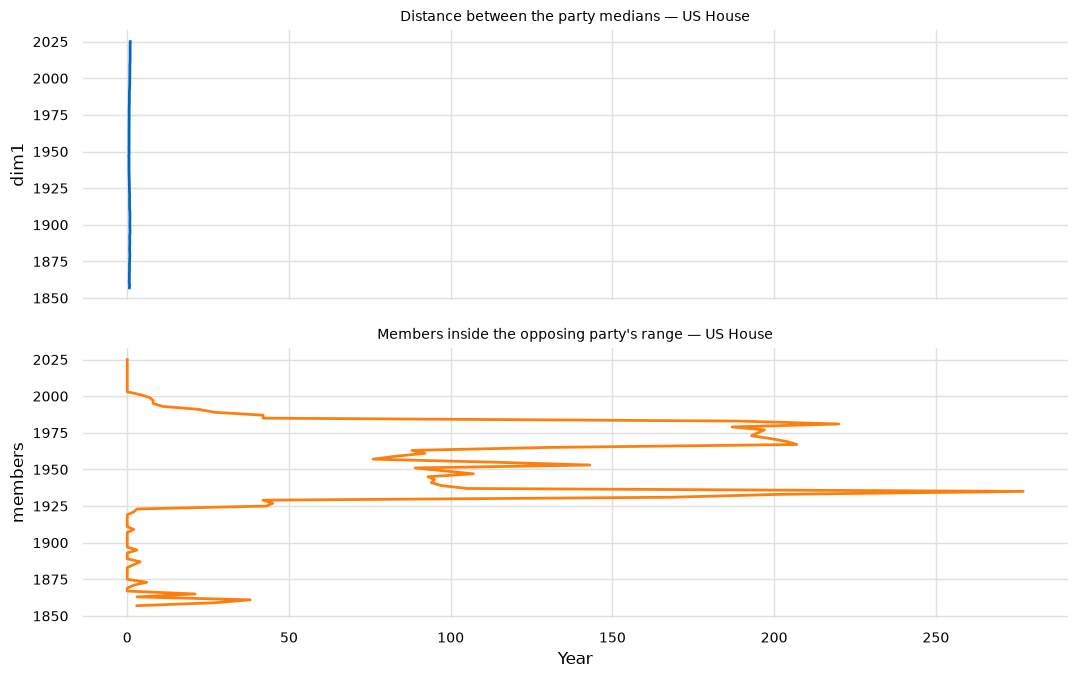

In [5]:
bloc = await get_series("voteview/moderate_bloc/house")
fig, (top, bottom) = pyplot.subplots(2, 1, figsize=(11, 7), sharex=True)
top.plot(*reversed(to_arrays(series)), lw=2)
top.set_ylabel(series["units"]); top.set_title(series["title"], fontsize=10)
bottom.plot(*reversed(to_arrays(bloc)), lw=2, color="tab:orange")
bottom.set_ylabel(bloc["units"]); bottom.set_xlabel("Year")
bottom.set_title(bloc["title"], fontsize=10)
fig.tight_layout()

The bloc reaches zero in 2007 and stays there while the gap keeps rising. The
parties went on separating after there was already nobody in between — which
is why both are stored rather than one standing in for the other.

## 5. Both chambers

The Senate tracks the House closely, which is worth knowing before treating
them as independent evidence.

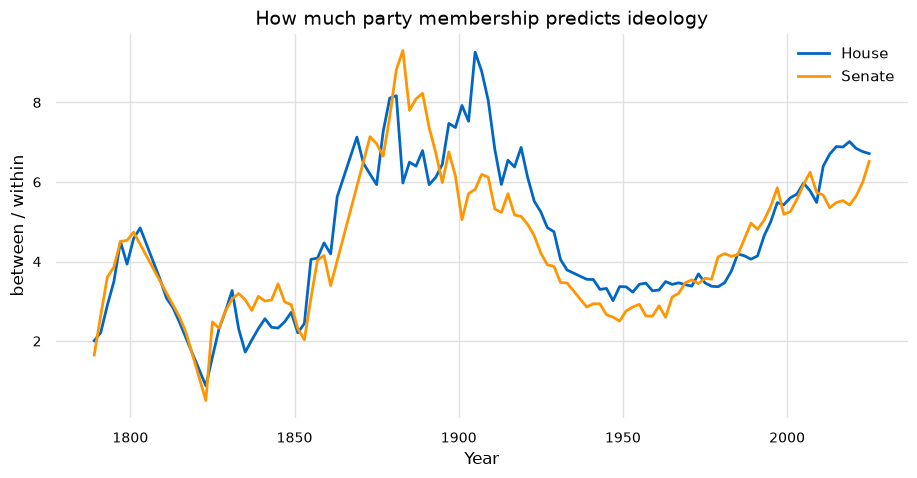

In [6]:
house = await get_series("voteview/party_predicts_position/house")
senate = await get_series("voteview/party_predicts_position/senate")
plot_group([house, senate], ["House", "Senate"],
           title="How much party membership predicts ideology",
           ylabel="between / within")


The gaps before 1857 are Congresses where one party held over 75% of the
chamber — the measure declines rather than compare a large median against a
remnant.

For the same numbers computed from the raw panel, with the reduction visible,
see [`client.ipynb`](client.ipynb).